In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [84]:
a = 0.02
b = 0.2
c = -65 
d = 2

def dv_dt(v, u, I):
    return 0.04*v**2 + 5*v + 140 - u + I

def du_dt(v, u, a, b):
    return a*(v*b-u)

def derivatives(vec, I, a, b):
    return np.array([dv_dt(vec[0], vec[1], I), du_dt(vec[0], vec[1], a, b)])

def I_input(t, ti):
    tau = 0.5
    return np.exp(-abs(t - ti)/tau)

def advanced_input(t, tis):
    suma = 0
    for item in tis:
        suma += I_input(t, item)
    return suma
    
def izikevich_model(weight, start, end, step):
    n = int((end - start) / step)
    t = np.linspace(start, end, n)
    
    listY = np.zeros((n, 2))
    listY[0] = [-65, -5]

    for i in range(1, n):
        I = I_input(t[i])
        
        listY[i] = listY[i-1] + step * derivatives(listY[i-1], weight * I,a,b)

        if listY[i][0] >= 30:
            listY[i][0] = c
            listY[i][1] += d

    return listY.T[0]

Construction of the Spiking Neural Network

In [78]:
def first_layer(n):
    outputs = []
    first_weights = np.random.rand(n)
    for i in range(n):
        outputs.append(izikevich_model(first_weights[i], 0, 5, 0.05))
    return outputs

def hidden_layers(list_numbers, prev_layer):
    m = len(list_numbers)
    for j in range(m):
        
        current_layer = []
        next_num = list_numbers[j]
        prev_num = len(prev_layer)
        current_weights = np.random.rand(next_num, prev_num)
        for h in range(next_num):
            current_layer.append(sum([current_weights[h][y] * prev_layer[y] for y in range(prev_num)]))

        prev_layer = current_layer
        if j == m - 1:
            return current_layer

def computation(first_layer_count, list_numbers):
    result = hidden_layers(list_numbers, first_layer(first_layer_count))[0]
    decode = 0
    for i in range(len(result) - 2):
        if result[i]  < result[i + 1]  and result[i + 1] > result[i + 2]:
            decode = decode + 1
    return decode


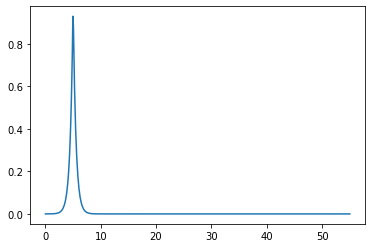

In [64]:
time = np.linspace(0, 55, 555)
y = [I_input(t) for t in time]
plt.plot(time, y)

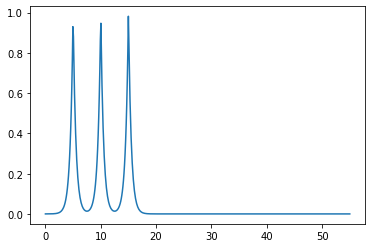

In [80]:
time = np.linspace(0, 55, 555)
tis = [5, 10, 15]
y = [advanced_input(t, tis) for t in time]
plt.plot(time, y)

[array([ -65.        ,  -65.        ,  -65.        ,  -65.        ,
        -65.        ,  -65.        ,  -65.        ,  -65.        ,
        -65.        ,  -65.        ,  -65.        ,  -65.        ,
        -65.        ,  -65.        ,  -65.        ,  -65.        ,
        -65.        ,  -65.        ,  -65.        ,  -65.        ,
        -65.        ,  -65.        ,  -65.        ,  -65.        ,
         24.43407326,  -65.        ,    7.4640196 ,  -65.        ,
         -6.4189653 ,  -65.        ,  -17.77953853,   28.59648347,
        -65.        ,  -31.02741302,    1.34594623,  -65.        ,
        -40.83550031,  -18.37898757,    4.65110254,  -65.        ,
        -50.04840954,  -36.55673279,  -23.6175213 ,  -10.43643622,
          3.84455685,   20.33469946,  -65.        ,  -59.41870073,
        -54.69579602,  -50.65159924,  -47.15462699,  -44.1055349 ,
        -41.42719479,  -39.05829109,  -36.94902884,  -35.05815819,
        -33.35084555,  -31.79710303,  -30.37059244,  -29.0476

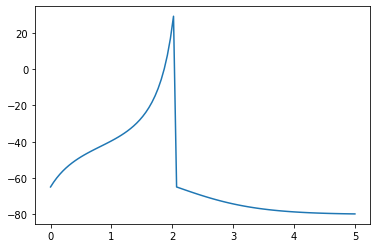

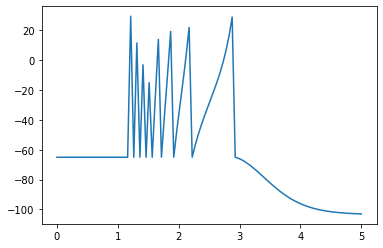

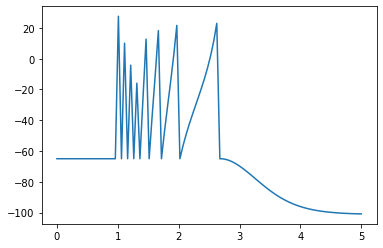

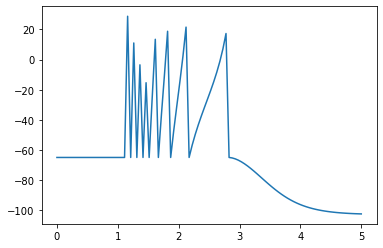

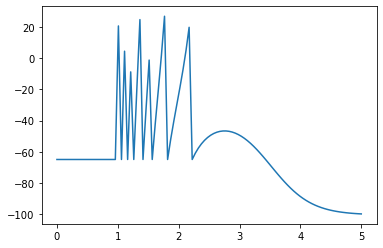

In [69]:
print(first_layer(5))
for i in first_layer(5):
    n = int(5 / 0.05)
    time = np.linspace(0, 5, n)
    plt.plot(time, i)
    plt.show()

[array([-344.94666186, -344.94666186, -344.94666186, -344.94666186,
       -344.94666186, -344.94666186, -344.94666186, -344.94666186,
       -344.94666186, -344.94666186, -344.94666186, -344.94666186,
       -344.94666186, -344.94666186, -344.94666186, -344.94666186,
       -344.94666186, -344.94666186, -344.94666186, -344.94666186,
       -344.94666186, -157.91197412,  -58.65350621, -193.29767539,
       -112.86587338, -222.24680194, -157.21670081, -245.93666939,
        -99.08280065,  -99.3796819 , -190.61412448, -127.25241762,
       -170.34321709, -235.24987827, -104.24599381,  -90.86516187,
        -77.08427839, -186.092716  , -229.72400154, -155.23052605,
        -80.41180668, -113.00823772, -148.19400152,  -88.17043757,
       -138.07417506, -191.6995505 , -267.62619966, -243.98552718,
       -222.36290175, -202.05570774, -182.39295563, -162.66700234,
       -142.05301163, -119.49471028,  -93.51932011, -177.63820113,
       -265.86792914, -265.56868654, -266.24042973, -267.7454

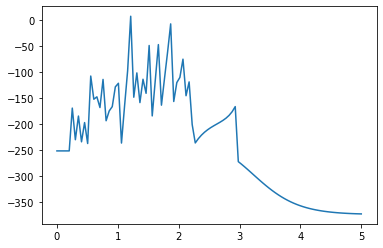

In [45]:
print(hidden_layers([5,1], first_layer(5)))
plt.plot(time,  hidden_layers([5,1], first_layer(5))[0])

In [57]:
print(computation(5, [5,1]))

19
